## Disney+ Recommendation Engine with Graphs 

This notebook is inspired from the work done by @yclaudel. @yclaudel shared a very nice notebook on the Netflix Movies and TV Shows data some time back. In this notebook, I have replicated his approach on the Disney+ dataset to generate recommendations for Disney+ content.

Original Source: https://www.kaggle.com/yclaudel/recommendation-engine-with-networkx/notebook

**Brief Summary of the approach:**  

1. Connect different tv shows / movies on Disney+ using a graph where each node represents a movie or a tv show. From the graph, measure the Adamic Adar Measure: higher this score for a node pair, closest the nodes are. The measures between all movies are NOT pre-calculated, in order to determine the list of recommendation films, we are going to explore the neighborhood of the target film
2. In order to take in account the description, calculate the TF-IDF matrix and for each film, take the top 5 of similar descriptions and create a node Similar_to_this. This node will be taken in account in the Adamic Adar measure.
3. In the graph, Nodes are : Movies, Person ( actor or director), Categories, Countries, Cluster (description), Sim(title) top 5 similar movies in the sense of the description
4. Edges are : ACTED_IN : relation between an actor and a movie, CAT_IN : relation between a categrie and a movie, DIRECTED : relation between a director and a movie, COU_IN : relation between a country and a movie, DESCRIPTION : relation between a cluster and a movie, SIMILARITY in the sense of the description. so, two movies are not directly connected, but they share persons, categories,clusters and countries. 
5. To generate the recommendations, explore the neighborhood of the target film, this is a list of actor, director, country, categories. Explore the neighborhood of each neighbor → discover the movies that share a node with the target field. Calculate Adamic Adar measure to give the final results.

Let's look at the dataset: 

In [1]:
#!/usr/bin/python
# -*- coding: utf-8 -*-

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math as math
import time
plt.style.use('seaborn')
plt.rcParams['figure.figsize'] = [14, 14]

df = pd.read_csv('../input/disney-movies-and-tv-shows/disney_plus_titles.csv')

df['date_added'] = pd.to_datetime(df['date_added'])
df['year'] = df['date_added'].dt.year
df['month'] = df['date_added'].dt.month
df['day'] = df['date_added'].dt.day

df['directors'] = df['director'].apply(lambda l: \
        ([] if pd.isna(l) else [i.strip() for i in l.split(',')]))
df['categories'] = df['listed_in'].apply(lambda l: \
        ([] if pd.isna(l) else [i.strip() for i in l.split(',')]))
df['actors'] = df['cast'].apply(lambda l: \
                                ([] if pd.isna(l) else [i.strip()
                                for i in l.split(',')]))
df['countries'] = df['country'].apply(lambda l: \
        ([] if pd.isna(l) else [i.strip() for i in l.split(',')]))

df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,month,day,directors,categories,actors,countries
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacN...",NaN,2021-11-26,2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!,2021.0,11.0,26.0,"[Alonso Ramirez Ramos, Dave Wasson]","[Animation, Family]","[Chris Diamantopoulos, Tony Anselmo, Tress Mac...",[]
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,2021-11-26,1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. ...,2021.0,11.0,26.0,[John Cherry],[Comedy],"[Jim Varney, Noelle Parker, Douglas Seale]",[]
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis L...",United States,2021-11-26,2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.,2021.0,11.0,26.0,[Karen Disher],"[Animation, Comedy, Family]","[Raymond Albert Romano, John Leguizamo, Denis ...",[United States]
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexa...",NaN,2021-11-26,2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!",2021.0,11.0,26.0,[Hamish Hamilton],[Musical],"[Darren Criss, Adam Lambert, Derek Hough, Alex...",[]
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, ...",NaN,2021-11-25,2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson ca...,2021.0,11.0,25.0,[],"[Docuseries, Historical, Music]","[John Lennon, Paul McCartney, George Harrison,...",[]


As the next step, build the tfidf matrix with the descriptions and find similar - get the top_n movies with description similar to the target description. This is followed by creation of Graph using the approach described above. 


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.cluster import MiniBatchKMeans

start_time = time.time()
text_content = df['description']
vector = TfidfVectorizer(
    max_df=0.4,
    min_df=1,
    stop_words='english',
    lowercase=True,
    use_idf=True,
    norm=u'l2',
    smooth_idf=True,
    )
tfidf = vector.fit_transform(text_content)

def find_similar(tfidf_matrix, index, top_n=5):
    cosine_similarities = linear_kernel(tfidf_matrix[index:index + 1],
            tfidf_matrix).flatten()
    related_docs_indices = [i for i in cosine_similarities.argsort()[::
                            -1] if i != index]
    return [index for index in related_docs_indices][0:top_n]

Create the graph using networkx

In [3]:
G = nx.Graph(label='MOVIE')
start_time = time.time()
for (i, rowi) in df.iterrows():
    G.add_node(rowi['title'], key=rowi['show_id'], label='MOVIE',
               mtype=rowi['type'], rating=rowi['rating'])
    for element in rowi['actors']:
        G.add_node(element, label='PERSON')
        G.add_edge(rowi['title'], element, label='ACTED_IN')
    for element in rowi['categories']:
        G.add_node(element, label='CAT')
        G.add_edge(rowi['title'], element, label='CAT_IN')
    for element in rowi['directors']:
        G.add_node(element, label='PERSON')
        G.add_edge(rowi['title'], element, label='DIRECTED')
    for element in rowi['countries']:
        G.add_node(element, label='COU')
        G.add_edge(rowi['title'], element, label='COU_IN')

    indices = find_similar(tfidf, i, top_n=5)
    snode = 'Sim(' + (rowi['title'])[:15].strip() + ')'
    G.add_node(snode, label='SIMILAR')
    G.add_edge(rowi['title'], snode, label='SIMILARITY')
    for element in indices:
        G.add_edge(snode, df['title'].loc[element], label='SIMILARITY')


def get_all_adj_nodes(list_in):
    sub_graph = set()
    for m in list_in:
        sub_graph.add(m)
        for e in G.neighbors(m):
            sub_graph.add(e)
    return list(sub_graph)


def draw_sub_graph(sub_graph, size='s'):
    subgraph = G.subgraph(sub_graph)
    colors = []
    for e in subgraph.nodes():
        if G.nodes[e]['label'] == 'MOVIE':
            colors.append('#96cdeb')
        elif G.nodes[e]['label'] == 'PERSON':
            colors.append('#ed859d')
        elif G.nodes[e]['label'] == 'CAT':
            colors.append('#9ce087')
        elif G.nodes[e]['label'] == 'COU':
            colors.append('#edf283')
        elif G.nodes[e]['label'] == 'SIMILAR':
            colors.append('#edb672')
        elif G.nodes[e]['label'] == 'CLUSTER':
            colors.append('#edb672')

    if size == 's':
        plt.figure(figsize=(8, 8))
    else:
        plt.figure(figsize=(15, 15))
    nx.draw(subgraph, with_labels=True, font_size=12,
            node_color=colors, edge_color='#c4c2be')
    plt.show()


def get_recommendation(root):
    commons_dict = {}
    for e in G.neighbors(root):
        for e2 in G.neighbors(e):
            if e2 == root:
                continue
            if G.nodes[e2]['label'] == 'MOVIE':
                commons = commons_dict.get(e2)
                if commons == None:
                    commons_dict.update({e2: [e]})
                else:
                    commons.append(e)
                    commons_dict.update({e2: commons})
    movies = []
    weight = []
    for (key, values) in commons_dict.items():
        w = 0.0
        for e in values:
            w = w + 1 / math.log(G.degree(e))
        movies.append(key)
        weight.append(w)

    result = pd.Series(data=np.array(weight), index=movies)
    result.sort_values(inplace=True, ascending=False)
    return result

def recommend(input_movie):
    print("*"*40+"\n\n Movie: "+input_movie+"\n\n"+"*"*40)

    list_in = [input_movie]
    sub_graph = get_all_adj_nodes(list_in)
    draw_sub_graph(sub_graph)

    result = get_recommendation(input_movie)
    print(result.head())

    print ("\n")
    print("*"*100+"\n\n Extended Recommendation with Attributes")
    # print ("\n")
    print("*"*100)

    reco=list(result.index[:4].values)
    reco.extend([input_movie])
    sub_graph = get_all_adj_nodes(reco)
    draw_sub_graph(sub_graph, size='w')

****************************************

 Movie: Marvel Studios' Iron Man 2

****************************************


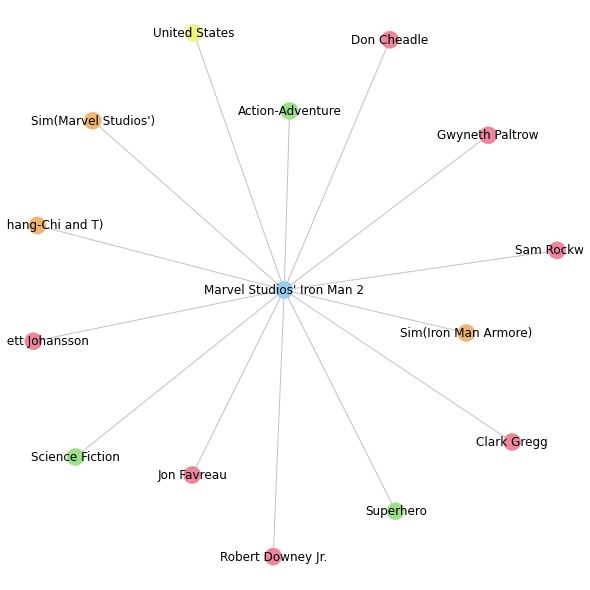

Marvel Studios' Iron Man                      3.577299
Marvel Studios' Iron Man 3                    3.182425
Marvel Studios: Assembling A Universe         2.797501
Marvel Studios' Captain America: Civil War    2.706480
Marvel Studios' Avengers: Infinity War        2.366857
dtype: float64


****************************************************************************************************

 Extended Recommendation with Attributes
****************************************************************************************************


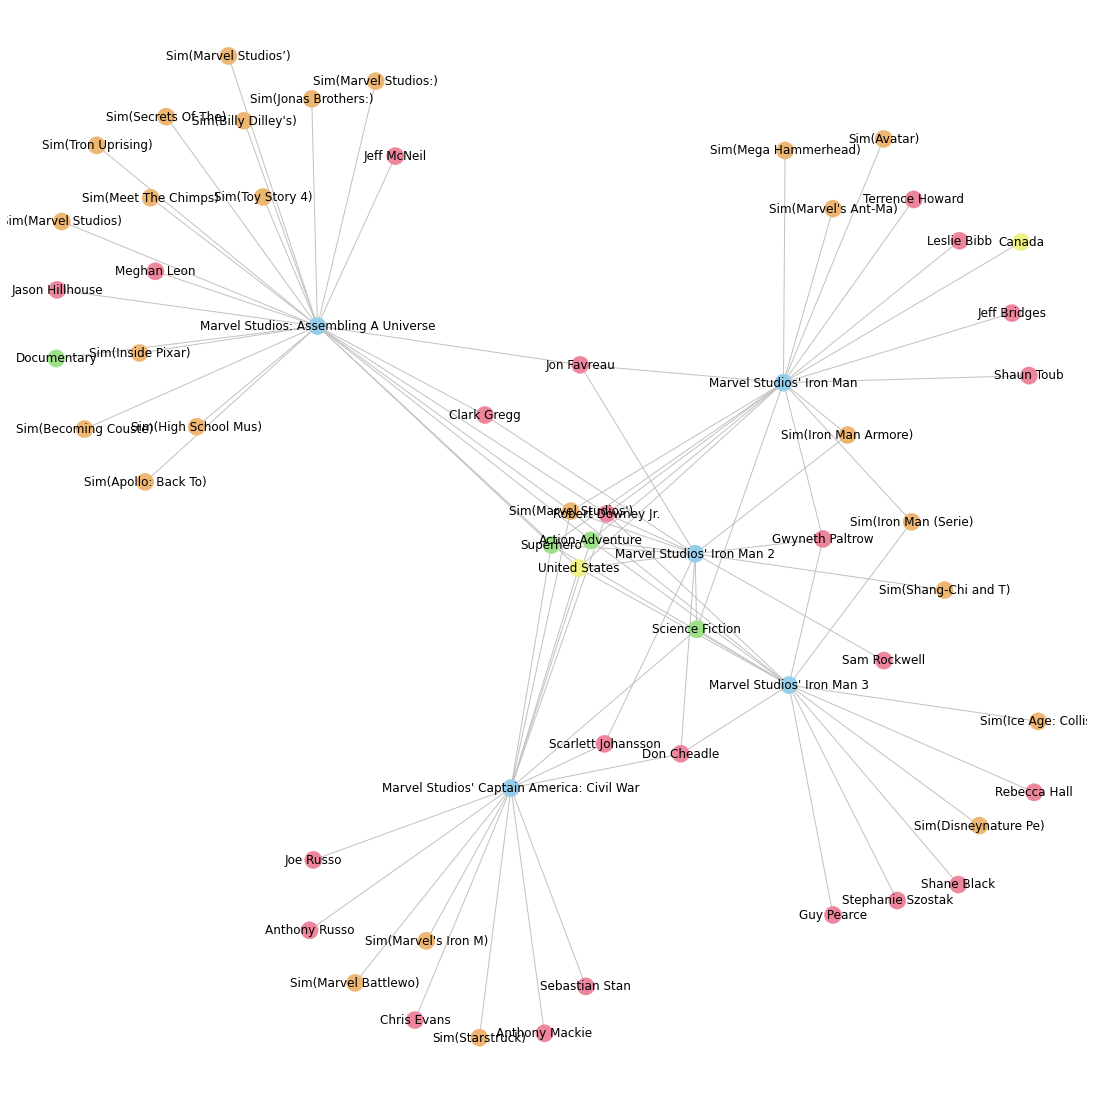

In [4]:
recommend("Marvel Studios' Iron Man 2")

****************************************

 Movie: X-Men Origins: Wolverine

****************************************


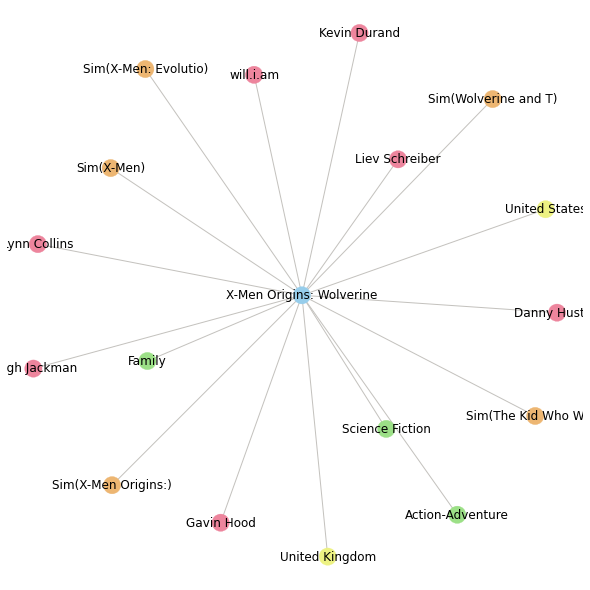

X-Men: First Class            2.975686
X-Men                         2.914072
X-Men: Days of Future Past    2.014530
X-Men: Evolution              1.979209
John Carter                   1.902638
dtype: float64


****************************************************************************************************

 Extended Recommendation with Attributes
****************************************************************************************************


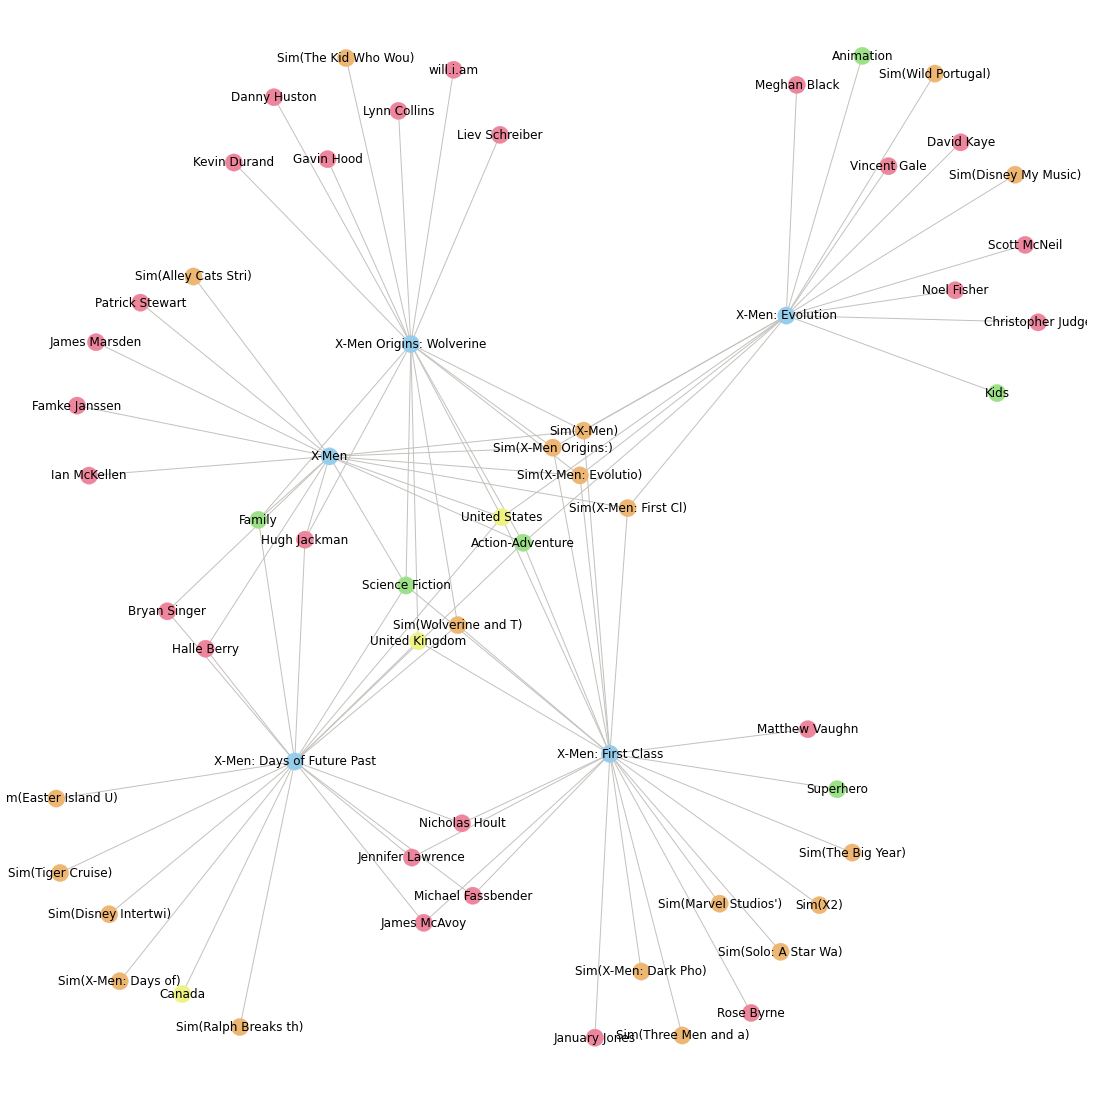

In [5]:
recommend("X-Men Origins: Wolverine")